In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/nppe-2-t-2-26-ecg-heartbeat-arrhythmia-classification/nppe2_dataset/sample_submission.csv
/kaggle/input/competitions/nppe-2-t-2-26-ecg-heartbeat-arrhythmia-classification/nppe2_dataset/train.csv
/kaggle/input/competitions/nppe-2-t-2-26-ecg-heartbeat-arrhythmia-classification/nppe2_dataset/test.csv


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
class CFG:
    DATA_DIR = "/kaggle/input/competitions/nppe-2-t-2-26-ecg-heartbeat-arrhythmia-classification/nppe2_dataset"
    TRAIN_DATA = f"{DATA_DIR}/train.csv"
    TEST_DATA = f"{DATA_DIR}/test.csv"
    SAMPLE_SUB = f"{DATA_DIR}/sample_submission.csv"

    SEED = 42
    BATCH_SIZE = 512
    EPOCHS = 40
    LR = 1e-3
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS = 2
    PATIENCE = 8

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BEST_MODEL = "/kaggle/working/best_ecg_cnn.pth"
    SUBMISSION = "submission.csv"


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG.SEED)
print("Device:", CFG.DEVICE)

Device: cuda


In [4]:
train_df = pd.read_csv(CFG.TRAIN_DATA)
test_df = pd.read_csv(CFG.TEST_DATA)
sample_submission = pd.read_csv(CFG.SAMPLE_SUB)

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("Sample submission:", sample_submission.shape)

display(train_df.head())
display(sample_submission.head())

Train: (71748, 255)
Test : (68914, 254)
Sample submission: (68914, 2)


,id,sig_0,sig_1,sig_2,sig_3,sig_4,sig_5,sig_6,sig_7,sig_8,...,sig_244,sig_245,sig_246,sig_247,sig_248,sig_249,pre_rr,post_rr,rr_ratio,label
0,tr_0000000,-0.45936,-0.47194,-0.44595,-0.46766,-0.47848,-0.44212,-0.40911,-0.39630,-0.42572,...,0.34128,0.34599,0.34956,0.34869,0.36385,0.34608,0.620,0.964,0.8378,2
1,tr_0000001,0.46701,0.41676,0.44001,0.46122,0.48141,0.48402,0.48774,0.46058,0.50425,...,0.36419,0.40048,0.40237,0.42921,0.42704,0.44949,1.148,1.128,1.0035,0
2,tr_0000002,-0.05439,-0.06101,-0.03403,-0.04836,-0.09790,-0.12191,-0.16152,-0.18606,-0.17850,...,0.23109,0.07517,-0.02015,-0.13179,-0.17835,-0.23683,0.588,0.580,1.0000,0
3,tr_0000003,0.02038,0.56312,0.93705,0.03558,-1.49486,-2.12957,-2.19772,-1.94957,-1.81099,...,0.36522,0.30252,0.53578,1.37349,2.55773,3.52536,0.496,0.496,1.0164,0
4,tr_0000004,-0.43263,-0.45353,-0.43887,-0.42160,-0.38072,-0.38062,-0.41078,-0.46798,-0.48628,...,-0.18767,-0.19071,-0.11951,-0.14097,-0.18661,-0.26196,0.892,0.896,0.9911,0


,id,label
0,te_0000000,0
1,te_0000001,0
2,te_0000002,0
3,te_0000003,0
4,te_0000004,0


In [5]:
SIGNAL_COLS = [f"sig_{i}" for i in range(250)]
RR_COLS = ["pre_rr", "post_rr", "rr_ratio"]
TARGET = "label"
ID_COL = "id"

assert all(c in train_df.columns for c in SIGNAL_COLS + RR_COLS + [TARGET, ID_COL])
assert all(c in test_df.columns for c in SIGNAL_COLS + RR_COLS + [ID_COL])

print("Signal columns:", len(SIGNAL_COLS))
print("RR columns:", RR_COLS)
print("Classes:", sorted(train_df[TARGET].unique()))

print("\nClass distribution:")
print(train_df[TARGET].value_counts().sort_index())
print("\nClass proportions:")
print(train_df[TARGET].value_counts(normalize=True).sort_index())

Signal columns: 250
RR columns: ['pre_rr', 'post_rr', 'rr_ratio']
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Class distribution:
label
0    45000
1     3599
2    22552
3      597
Name: count, dtype: int64

Class proportions:
label
0    0.627195
1    0.050162
2    0.314322
3    0.008321
Name: proportion, dtype: float64


In [6]:
print("Train missing values:")
print(train_df[SIGNAL_COLS + RR_COLS + [TARGET]].isna().sum().loc[lambda s: s > 0])

print("\nTest missing values:")
print(test_df[SIGNAL_COLS + RR_COLS].isna().sum().loc[lambda s: s > 0])

print("\nTrain numeric infinities:", np.isinf(train_df.select_dtypes(include=np.number)).any().any())
print("Test numeric infinities :", np.isinf(test_df.select_dtypes(include=np.number)).any().any())

Train missing values:
pre_rr       7
post_rr     17
rr_ratio     7
dtype: int64

Test missing values:
pre_rr      13
post_rr     10
rr_ratio    13
dtype: int64

Train numeric infinities: False
Test numeric infinities : False


In [7]:
rr_medians = train_df[RR_COLS].median()

train_df[RR_COLS] = train_df[RR_COLS].fillna(rr_medians)
test_df[RR_COLS] = test_df[RR_COLS].fillna(rr_medians)

assert not train_df[SIGNAL_COLS + RR_COLS].isna().any().any()
assert not test_df[SIGNAL_COLS + RR_COLS].isna().any().any()

print("Missing RR values filled with:", rr_medians.to_dict())

Missing RR values filled with: {'pre_rr': 0.652, 'post_rr': 0.764, 'rr_ratio': 0.9627}


In [8]:
X_signal = train_df[SIGNAL_COLS].to_numpy(dtype=np.float32)
X_rr = train_df[RR_COLS].to_numpy(dtype=np.float32)
y = train_df[TARGET].to_numpy(dtype=np.int64)

X_signal_test = test_df[SIGNAL_COLS].to_numpy(dtype=np.float32)
X_rr_test = test_df[RR_COLS].to_numpy(dtype=np.float32)

indices = np.arange(len(y))

train_idx, val_idx = train_test_split(
                indices,
                test_size=0.20,
                random_state=CFG.SEED,
                shuffle=True,
                stratify=y,
)

print("Train:", len(train_idx))
print("Val  :", len(val_idx))

print("\nTrain class counts:")
print(pd.Series(y[train_idx]).value_counts().sort_index())

print("\nVal class counts:")
print(pd.Series(y[val_idx]).value_counts().sort_index())


Train: 57398
Val  : 14350

Train class counts:
0    36000
1     2879
2    18041
3      478
Name: count, dtype: int64

Val class counts:
0    9000
1     720
2    4511
3     119
Name: count, dtype: int64


In [9]:
USE_BEAT_NORMALIZATION = True

def normalize_each_beat(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    std = np.maximum(std, 1e-6)
    return (X - mean) / std

X_sig_train = X_signal[train_idx].copy()
X_sig_val = X_signal[val_idx].copy()
X_rr_train = X_rr[train_idx].copy()
X_rr_val = X_rr[val_idx].copy()
y_train = y[train_idx].copy()
y_val = y[val_idx].copy()

if USE_BEAT_NORMALIZATION:
    X_sig_train = normalize_each_beat(X_sig_train)
    X_sig_val = normalize_each_beat(X_sig_val)
    X_sig_test = normalize_each_beat(X_signal_test)
else:
    X_sig_test = X_signal_test.copy()

rr_scaler = StandardScaler()
X_rr_train = rr_scaler.fit_transform(X_rr_train).astype(np.float32)
X_rr_val = rr_scaler.transform(X_rr_val).astype(np.float32)
X_rr_test = rr_scaler.transform(X_rr_test).astype(np.float32)

print("Signal train:", X_sig_train.shape)
print("RR train    :", X_rr_train.shape)
print("Labels train:", y_train.shape)

Signal train: (57398, 250)
RR train    : (57398, 3)
Labels train: (57398,)


In [10]:
X_sig_train = torch.from_numpy(X_sig_train).unsqueeze(1)  # [N, 1, 250]
X_sig_val = torch.from_numpy(X_sig_val).unsqueeze(1)
X_sig_test = torch.from_numpy(X_sig_test).unsqueeze(1)

X_rr_train = torch.from_numpy(X_rr_train)
X_rr_val = torch.from_numpy(X_rr_val)
X_rr_test = torch.from_numpy(X_rr_test)

y_train = torch.from_numpy(y_train)
y_val = torch.from_numpy(y_val)

print("Signal:", X_sig_train.shape)
print("RR    :", X_rr_train.shape)
print("Label :", y_train.shape)

Signal: torch.Size([57398, 1, 250])
RR    : torch.Size([57398, 3])
Label : torch.Size([57398])


In [11]:
train_data = TensorDataset(X_sig_train, X_rr_train, y_train)
val_data = TensorDataset(X_sig_val, X_rr_val, y_val)

loader_kwargs = {
    "batch_size": CFG.BATCH_SIZE,
    "num_workers": CFG.NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}

if CFG.NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(train_data, shuffle=True, drop_last=False, **loader_kwargs)
val_loader = DataLoader(val_data, shuffle=False, drop_last=False, **loader_kwargs)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train batches: 113
Val batches  : 29


In [12]:
class ECG_CNN(nn.Module):
    def __init__(self, rr_dim=3, num_classes=4):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),

            nn.Conv1d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool1d(1),
        )

        self.rr_net = nn.Sequential(
            nn.Linear(rr_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 + 32, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(64, num_classes),
        )

    def forward(self, signal, rr):
        x = self.cnn(signal).squeeze(-1)
        r = self.rr_net(rr)
        x = torch.cat([x, r], dim=1)
        return self.classifier(x)

model = ECG_CNN(rr_dim=len(RR_COLS), num_classes=4).to(CFG.DEVICE)

print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))

ECG_CNN(
  (cnn): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (12): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
  

In [13]:
# Does not give the best result but performs well
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
            
        return focal_loss

In [14]:
classes = np.array([0, 1, 2, 3])

balanced_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.numpy())
class_weights = torch.tensor(balanced_weights, dtype=torch.float32, device=CFG.DEVICE)

print("Balanced class weights:")
for c, w in zip(classes, balanced_weights):
    print(f"Class {c}: {w:.4f}")

# GAMMA = 2.0
# criterion = FocalLoss(alpha=class_weights, gamma=GAMMA)
# print(f"\nFocal Loss: gamma={GAMMA}")
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-6)

Balanced class weights:
Class 0: 0.3986
Class 1: 4.9842
Class 2: 0.7954
Class 3: 30.0199


In [15]:
def macro_f1_from_logits(logits, labels):
    preds = logits.argmax(dim=1).detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()
    return f1_score(labels,preds, average="macro", labels=[0, 1, 2, 3], zero_division=0)

def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip=5.0):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for signal, rr, labels in loader:
        signal = signal.to(device, non_blocking=True)
        rr = rr.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(signal, rr)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        all_preds.append(logits.argmax(dim=1).detach().cpu())
        all_labels.append(labels.detach().cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    loss = running_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro", labels=[0, 1, 2, 3], zero_division=0)

    return loss, f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    for signal, rr, labels in loader:
        signal = signal.to(device, non_blocking=True)
        rr = rr.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(signal, rr)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        running_loss += loss.item() * labels.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    loss = running_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro", labels=[0, 1, 2, 3], zero_division=0)

    return loss, f1, all_preds, all_labels, all_probs


In [16]:
history = {
    "train_loss": [],
    "train_f1": [],
    "val_loss": [],
    "val_f1": [],
    "lr": [],
}

best_f1 = -np.inf
epochs_without_improvement = 0

for epoch in range(1, CFG.EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, CFG.DEVICE)
    val_loss, val_f1, _, _, _ = evaluate(model, val_loader, criterion, CFG.DEVICE)
    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:02d}/{CFG.EPOCHS} | "
        f"train loss {train_loss:.4f} | "
        f"train F1 {train_f1:.4f} | "
        f"val loss {val_loss:.4f} | "
        f"val Macro F1 {val_f1:.4f} | "
        f"lr {current_lr:.2e}"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        epochs_without_improvement = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_f1": best_f1,
                "rr_scaler": rr_scaler,
                "rr_medians": rr_medians.to_dict(),
                "use_beat_normalization": USE_BEAT_NORMALIZATION,
            },
            CFG.BEST_MODEL,
        )
        print(f"  -> saved best model: {best_f1:.4f}")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= CFG.PATIENCE:
        print("Early stopping.")
        break

print(f"\nBest validation Macro F1: {best_f1:.4f}")


Epoch 01/40 | train loss 0.5952 | train F1 0.5716 | val loss 0.2846 | val Macro F1 0.6934 | lr 1.00e-03
  -> saved best model: 0.6934
Epoch 02/40 | train loss 0.3030 | train F1 0.7043 | val loss 0.2901 | val Macro F1 0.7385 | lr 1.00e-03
  -> saved best model: 0.7385
Epoch 03/40 | train loss 0.2593 | train F1 0.7289 | val loss 0.2118 | val Macro F1 0.7538 | lr 1.00e-03
  -> saved best model: 0.7538
Epoch 04/40 | train loss 0.2240 | train F1 0.7438 | val loss 0.2122 | val Macro F1 0.7488 | lr 1.00e-03
Epoch 05/40 | train loss 0.2207 | train F1 0.7466 | val loss 0.2420 | val Macro F1 0.6763 | lr 1.00e-03
Epoch 06/40 | train loss 0.1931 | train F1 0.7582 | val loss 0.2221 | val Macro F1 0.8103 | lr 1.00e-03
  -> saved best model: 0.8103
Epoch 07/40 | train loss 0.1863 | train F1 0.7645 | val loss 0.1594 | val Macro F1 0.7884 | lr 1.00e-03
Epoch 08/40 | train loss 0.1652 | train F1 0.7783 | val loss 0.2504 | val Macro F1 0.8378 | lr 1.00e-03
  -> saved best model: 0.8378
Epoch 09/40 | trai

In [17]:
checkpoint = torch.load(CFG.BEST_MODEL, map_location=CFG.DEVICE, weights_only = False)
model.load_state_dict(checkpoint["model_state_dict"])
final_val_loss, final_val_f1, val_preds, val_labels, val_probs = evaluate(model, val_loader, criterion, CFG.DEVICE)
print("Best checkpoint Macro F1:", final_val_f1)

class_names = {
    0: "Normal",
    1: "Supraventricular Ectopic",
    2: "Ventricular Ectopic",
    3: "Fusion",
}

print(classification_report(val_labels, val_preds, labels=[0, 1, 2, 3], target_names=[class_names[i] for i in range(4)], digits=4, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(val_labels, val_preds, labels=[0, 1, 2, 3]))
print("\nValidation prediction distribution:")
print(pd.Series(val_preds).value_counts().sort_index())


Best checkpoint Macro F1: 0.8902398957058255
                          precision    recall  f1-score   support

                  Normal     0.9957    0.9841    0.9899      9000
Supraventricular Ectopic     0.9023    0.9750    0.9372       720
     Ventricular Ectopic     0.9875    0.9805    0.9840      4511
                  Fusion     0.5202    0.8655    0.6498       119

                accuracy                         0.9815     14350
               macro avg     0.8514    0.9513    0.8902     14350
            weighted avg     0.9845    0.9815    0.9826     14350

Confusion matrix:
[[8857   62   43   38]
 [  11  702    7    0]
 [  18   13 4423   57]
 [   9    1    6  103]]

Validation prediction distribution:
0    8895
1     778
2    4479
3     198
Name: count, dtype: int64


In [18]:
per_class_f1 = f1_score(val_labels, val_preds, average=None, labels=[0, 1, 2, 3], zero_division=0)

per_class_table = pd.DataFrame({
    "class_id": [0, 1, 2, 3],
    "class_name": [class_names[i] for i in range(4)],
    "f1": per_class_f1,
    "true_count": np.bincount(val_labels, minlength=4),
    "pred_count": np.bincount(val_preds, minlength=4),
})

display(per_class_table)
print(f"Global Macro F1: {f1_score(val_labels, val_preds, average='macro', zero_division=0):.5f}")


,class_id,class_name,f1,true_count,pred_count
0,0,Normal,0.989885,9000,8895
1,1,Supraventricular Ectopic,0.937250,720,778
2,2,Ventricular Ectopic,0.983982,4511,4479
3,3,Fusion,0.649842,119,198


Global Macro F1: 0.89024


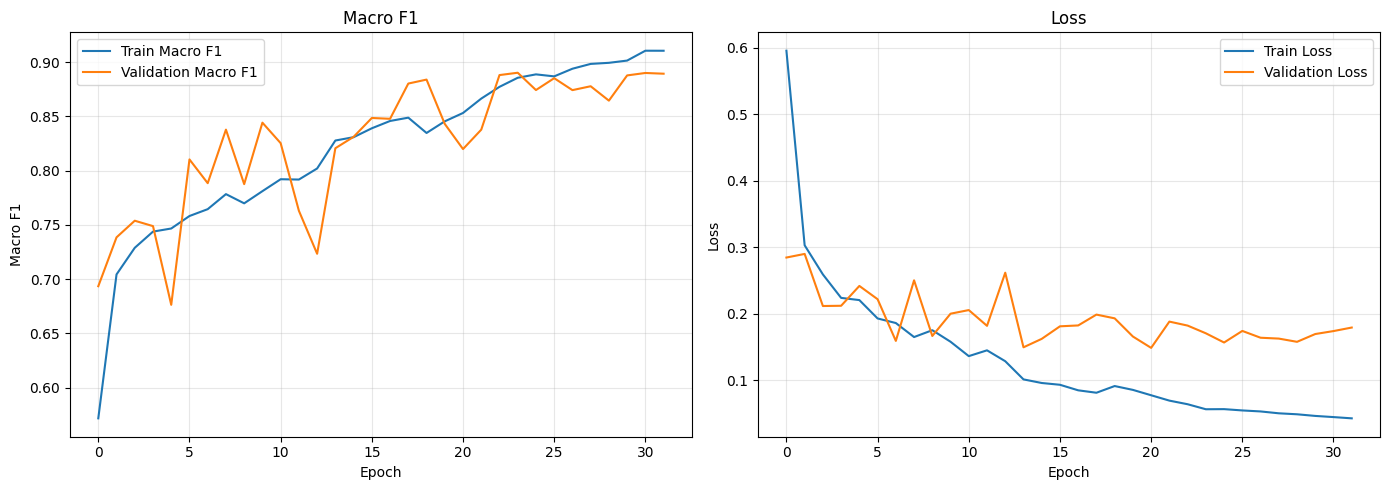

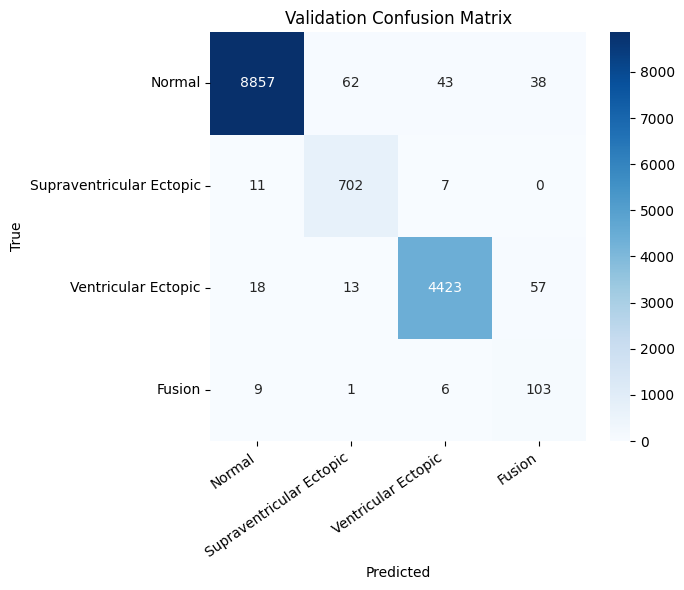

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_f1"], label="Train Macro F1")
axes[0].plot(history["val_f1"], label="Validation Macro F1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Macro F1")
axes[0].set_title("Macro F1")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_loss"], label="Train Loss")
axes[1].plot(history["val_loss"], label="Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

cm = confusion_matrix(val_labels, val_preds, labels=[0, 1, 2, 3])

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[class_names[i] for i in range(4)], yticklabels=[class_names[i] for i in range(4)])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Validation Confusion Matrix")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


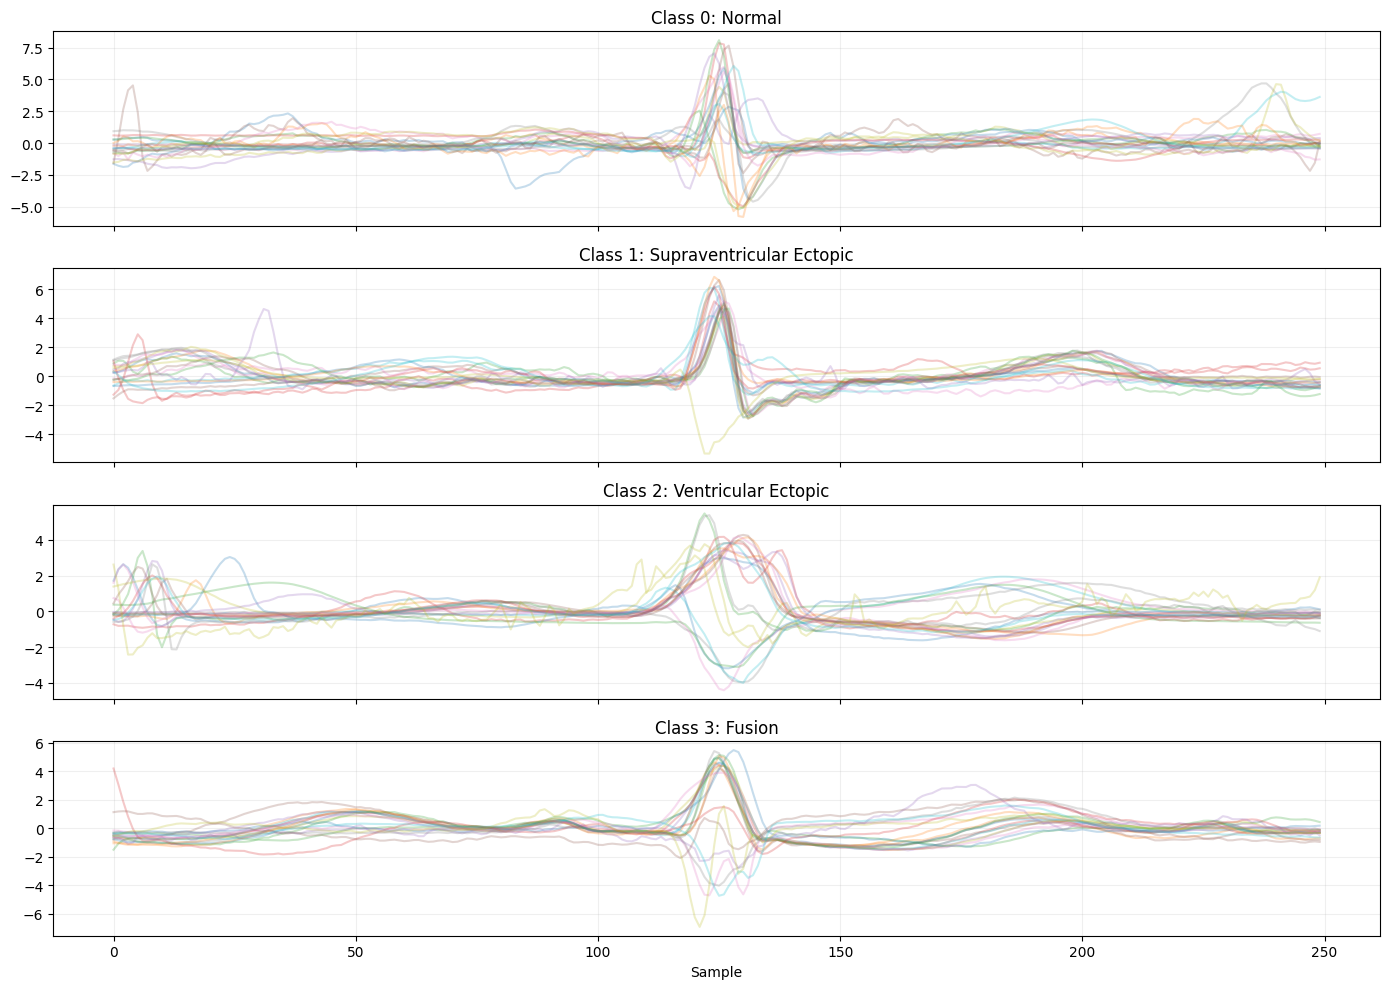

In [20]:
rng = np.random.default_rng(CFG.SEED)
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for class_id, ax in enumerate(axes):
    class_indices = np.where(y_train.numpy() == class_id)[0]
    if len(class_indices) == 0:
        continue

    chosen = rng.choice(class_indices, size=min(20, len(class_indices)), replace=False)
    for i in chosen:
        ax.plot(X_sig_train[i].squeeze(0), alpha=0.25)

    ax.set_title(f"Class {class_id}: {class_names[class_id]}")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()


In [21]:
class TestDataset(Dataset):
    def __init__(self, ids, signals, rr):
        self.ids = list(ids)
        self.signals = signals
        self.rr = rr

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        return self.ids[idx], self.signals[idx], self.rr[idx]

test_data = TestDataset(test_df[ID_COL].tolist(), X_sig_test, X_rr_test,)
test_loader = DataLoader(test_data, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=torch.cuda.is_available(), persistent_workers=(CFG.NUM_WORKERS > 0))
print("Test samples:", len(test_data))


Test samples: 68914


In [22]:
@torch.no_grad()
def predict_test(model, loader, device):
    model.eval()

    ids = []
    predictions = []
    probabilities = []

    for batch_ids, signal, rr in loader:
        signal = signal.to(device, non_blocking=True)
        rr = rr.to(device, non_blocking=True)

        logits = model(signal, rr)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        ids.extend(batch_ids)
        predictions.extend(preds.cpu().numpy())
        probabilities.append(probs.cpu().numpy())
    probabilities = np.concatenate(probabilities, axis=0)
    return ids, np.asarray(predictions), probabilities


test_ids, test_preds, test_probs = predict_test(model, test_loader, CFG.DEVICE)

print("Predictions:", test_preds.shape)
print("Probability matrix:", test_probs.shape)

print("\nTest prediction distribution:")
print(pd.Series(test_preds).value_counts().sort_index())


Predictions: (68914,)
Probability matrix: (68914, 4)

Test prediction distribution:
0    59861
1     4379
2     4332
3      342
Name: count, dtype: int64


In [23]:
submission = sample_submission.copy()

submission[TARGET] = test_preds

assert len(submission) == len(test_df)
assert list(submission.columns) == list(sample_submission.columns)

submission.to_csv(CFG.SUBMISSION, index=False)

print(submission.head())
print("Submission shape:", submission.shape)
print("Saved to:", CFG.SUBMISSION)


           id  label
0  te_0000000      1
1  te_0000001      0
2  te_0000002      0
3  te_0000003      0
4  te_0000004      0
Submission shape: (68914, 2)
Saved to: submission.csv
